# **Import Everthing**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import math
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,
                             classification_report,
                             confusion_matrix)
print('Everything is loaded')

Everything is loaded


# **Data Exploration**

## **Load The Data**

In [2]:
file_path = input("Enter the File Path Baby: ")
df = pd.read_csv(file_path)
print('Data Loaded Baby')

Data Loaded Baby


## **Exploration**

In [3]:
print(f'The dataset have {df.shape[0]} Rows and {df.shape[1]} columns with {df.duplicated().sum()} Duplicates')

The dataset have 32300 Rows and 10 columns with 300 Duplicates


In [4]:
df.sample(10)

,loan_amount,annual_income,credit_score,loan_term_years,employment_years,num_open_loans,debt_to_income,collateral_value,missed_payments,defaulted
9814,1954037.42,3906155.61,520.0,20.0,10.3,3.0,0.184,647632.67,5.0,1
3770,223799.00,3488998.95,820.0,15.0,18.5,2.0,0.130,2911595.66,0.0,0
526,481981.10,2500424.81,348.0,3.0,13.6,1.0,0.169,1721944.43,5.0,1
5494,843464.61,320362.15,699.0,10.0,5.8,4.0,0.345,123994.96,2.0,1
3093,1063958.21,1479082.56,691.0,3.0,22.4,3.0,0.096,1091084.97,3.0,0
10284,108138.71,3143236.26,NaN,NaN,28.7,4.0,0.579,2238355.46,5.0,1
17702,1351506.02,2012559.07,415.0,5.0,12.4,3.0,0.576,216916.62,5.0,1
16714,1116530.50,3283122.95,736.0,5.0,28.8,6.0,0.550,1641231.40,5.0,1
1275,385291.87,2649347.71,830.0,3.0,6.4,2.0,0.118,1074117.71,1.0,0
10654,366546.95,4833115.24,845.0,20.0,29.5,2.0,0.486,344987.02,2.0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32300 entries, 0 to 32299
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   loan_amount       31650 non-null  float64
 1   annual_income     31656 non-null  float64
 2   credit_score      31654 non-null  str    
 3   loan_term_years   31651 non-null  float64
 4   employment_years  31654 non-null  float64
 5   num_open_loans    31651 non-null  float64
 6   debt_to_income    31653 non-null  float64
 7   collateral_value  31657 non-null  float64
 8   missed_payments   31655 non-null  float64
 9   defaulted         32300 non-null  int64  
dtypes: float64(8), int64(1), str(1)
memory usage: 2.6 MB


In [6]:
df.describe()

,loan_amount,annual_income,loan_term_years,employment_years,num_open_loans,debt_to_income,collateral_value,missed_payments,defaulted
count,3.165000e+04,3.165600e+04,31651.000000,31654.000000,31651.000000,31653.000000,3.165700e+04,31655.000000,32300.000000
mean,1.004623e+06,2.544057e+06,8.000537,14.972297,3.468421,0.325485,1.500723e+06,2.487095,0.499226
std,5.742106e+05,1.419997e+06,6.714595,8.640762,2.285190,0.160174,8.684293e+05,1.708161,0.500007
min,-5.000000e+04,-1.000000e+04,1.000000,-5.000000,-2.000000,0.050000,2.400700e+02,-3.000000,0.000000
25%,5.073849e+05,1.306325e+06,2.000000,7.500000,1.000000,0.189000,7.513584e+05,1.000000,0.000000
50%,1.006422e+06,2.537639e+06,5.000000,15.000000,3.000000,0.325000,1.495951e+06,2.000000,0.000000
75%,1.498466e+06,3.778322e+06,15.000000,22.500000,5.000000,0.462000,2.261343e+06,4.000000,1.000000
max,1.999993e+06,4.999979e+06,20.000000,30.000000,7.000000,5.000000,2.999922e+06,5.000000,1.000000


In [7]:
df.isna().sum()

loan_amount         650
annual_income       644
credit_score        646
loan_term_years     649
employment_years    646
num_open_loans      649
debt_to_income      647
collateral_value    643
missed_payments     645
defaulted             0
dtype: int64

# **Data Cleaning**

## **Create Copy**

In [8]:
df_copy = df.copy()
print('copy Created Boss')

copy Created Boss


## **DataType**

In [9]:
df_copy['credit_score'] = df_copy['credit_score'].replace('_err','',regex=True).astype('float')

## **Impossible Values**

In [10]:
Columns = df_copy.columns.tolist()

for col in Columns:
    df_copy.loc[df_copy[col]<0,col] = np.nan

df_copy.loc[df_copy['credit_score']>900,'credit_score'] = np.nan

## **Outliers**

In [11]:
Columns = ['loan_amount','annual_income','credit_score','debt_to_income','collateral_value']

for col in Columns:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_copy.loc[df_copy[col] < lower, col] = np.nan
    df_copy.loc[df_copy[col] > upper, col] = np.nan

print("Outliers Handled ✅")

Outliers Handled ✅


## **Duplicates**

In [12]:
print("Dateset have duplicates: ")
print(f"Before: {df_copy.duplicated().sum()}")
df_copy.drop_duplicates(inplace=True)
print(f"After: {df_copy.duplicated().sum()}")

Dateset have duplicates: 
Before: 300
After: 0


## **NaN values**

In [13]:
print("NaN values in the Dataset is: ")
print(df_copy.isna().sum())

Round = ['loan_amount','annual_income','employment_years','debt_to_income','collateral_value']

for col in Round:
    df_copy[col] = df_copy[col].fillna(round(df_copy[col].median(),2))
    
Floor = ['credit_score','loan_term_years','num_open_loans','missed_payments']
for col in Floor:
    df_copy[col] = df_copy[col].fillna(math.floor(df_copy[col].median()))
    
print("NaN values in the Dataset After Cleaning is: ")
print(df_copy.isna().sum())

NaN values in the Dataset is: 
loan_amount         641
annual_income       641
credit_score        641
loan_term_years     640
employment_years    641
num_open_loans      641
debt_to_income      641
collateral_value    640
missed_payments     641
defaulted             0
dtype: int64
NaN values in the Dataset After Cleaning is: 
loan_amount         0
annual_income       0
credit_score        0
loan_term_years     0
employment_years    0
num_open_loans      0
debt_to_income      0
collateral_value    0
missed_payments     0
defaulted           0
dtype: int64


# **Data Preperation**

In [14]:
features = df_copy.columns.tolist()
features.remove('defaulted')
X = df_copy[features]
y = df_copy['defaulted']
print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

X Shape: (32000, 9)
y Shape: (32000,)


In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,train_size=0.8)

print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape:  {X_test.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"y_test Shape:  {y_test.shape}")

X_train Shape: (25600, 9)
X_test Shape:  (6400, 9)
y_train Shape: (25600,)
y_test Shape:  (6400,)


In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# **Model**

## **Train**

In [17]:
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=20,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)

print(f"Best trees used: {model.best_iteration}")
print(f"Model trained ✅")

Best trees used: 111
Model trained ✅


## **Evaluation & Pridict**

In [18]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

         0.0       0.83      0.83      0.83      3199
         1.0       0.83      0.83      0.83      3201

    accuracy                           0.83      6400
   macro avg       0.83      0.83      0.83      6400
weighted avg       0.83      0.83      0.83      6400

Accuracy: 0.8300


## **Feature importance**

In [19]:
importance_types = ['weight', 'gain', 'cover']

for imp_type in importance_types:
    imp = model.get_booster().get_score(importance_type=imp_type)
    print(f"\n{imp_type.upper()}:")
    for feat, score in sorted(imp.items(), key=lambda x: x[1], reverse=True):
        print(f"  {feat:25} → {score:.4f}")


WEIGHT:
  f0                        → 591.0000
  f2                        → 579.0000
  f1                        → 559.0000
  f6                        → 476.0000
  f4                        → 451.0000
  f7                        → 418.0000
  f5                        → 321.0000
  f8                        → 309.0000
  f3                        → 276.0000

GAIN:
  f8                        → 63.4647
  f2                        → 34.4466
  f1                        → 29.4765
  f0                        → 19.9972
  f3                        → 16.6556
  f5                        → 15.7810
  f4                        → 8.7638
  f6                        → 8.4330
  f7                        → 6.5677

COVER:
  f8                        → 1041.4459
  f2                        → 601.8600
  f1                        → 585.9874
  f3                        → 572.5626
  f5                        → 560.2580
  f0                        → 462.0156
  f4                        → 330.3320
  f6        

## **OverFitting Check**

In [20]:
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
test_acc  = accuracy_score(y_test,  y_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Gap:               {(train_acc - test_acc):.4f}")
print(f"Best iteration:    {model.best_iteration}")

Training Accuracy: 0.8621
Testing Accuracy:  0.8300
Gap:               0.0321
Best iteration:    111


## **Charts**

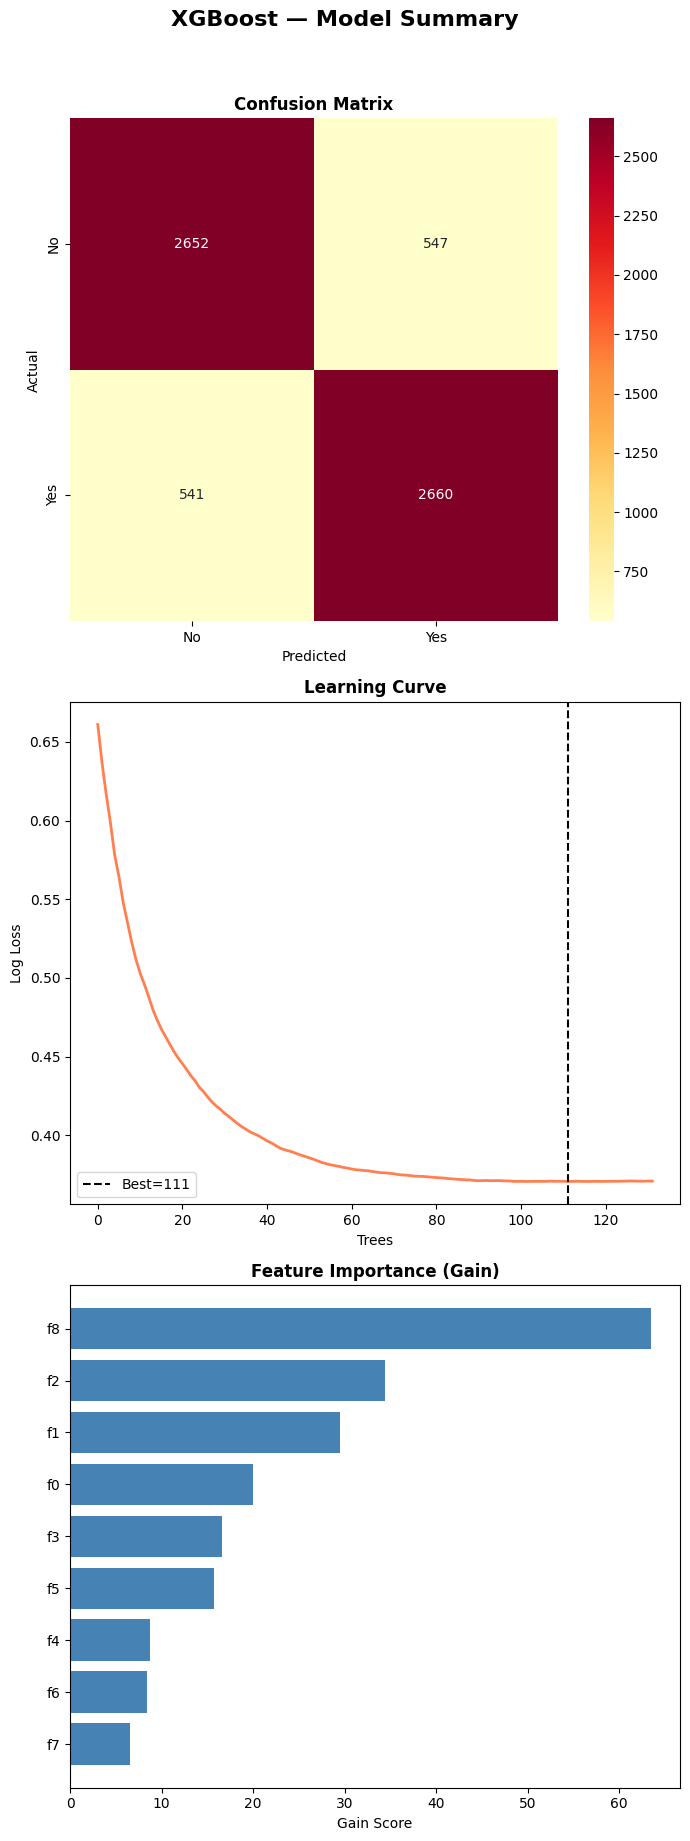

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(7, 18))

# Plot 1 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot 2 — Learning Curve
results = model.evals_result()
axes[1].plot(results['validation_0']['logloss'],
             color='coral', linewidth=2)
axes[1].axvline(model.best_iteration, linestyle='--',
                color='black', label=f'Best={model.best_iteration}')
axes[1].set_title('Learning Curve', fontweight='bold')
axes[1].set_xlabel('Trees')
axes[1].set_ylabel('Log Loss')
axes[1].legend()

# Plot 3 — Feature Importance (Gain)
imp_df = pd.DataFrame(
    model.get_booster().get_score(importance_type='gain').items(),
    columns=['Feature', 'Gain']
).sort_values('Gain')
axes[2].barh(imp_df['Feature'], imp_df['Gain'], color='steelblue')
axes[2].set_title('Feature Importance (Gain)', fontweight='bold')
axes[2].set_xlabel('Gain Score')

plt.suptitle('XGBoost — Model Summary',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()